**Імпорт потрібних інструментів та бібліотек.**

На початку роботи підключаємо бібліотеки, які потрібні для всього подальшого аналізу кліматичних даних. `pandas` використовується як основний інструмент для зчитування CSV-файлу, очищення таблиці, перетворення форматів та обчислення підсумкових показників.

Для статистичного моделювання підключаємо `scipy.stats`, зокрема метод `linregress`, який дозволяє оцінити лінійний тренд температури, отримати кут нахилу, вільний член та базові статистичні характеристики моделі.

Для візуалізації результатів використовуємо `matplotlib` і `seaborn`. Ці бібліотеки дають змогу будувати інформативні графіки, порівнювати фактичні та прогнозовані значення, а також наочно показати довгострокову тенденцію зміни середньої температури у часі.

Такий набір інструментів є достатнім для повного циклу аналізу: від завантаження даних до побудови регресійної моделі, оцінки похибки прогнозу та формування обґрунтованих висновків.

In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

**Завантаження даних із зовнішнього джерела**

У цьому блоці задаємо посилання на CSV-файл із відкритими даними NOAA та зчитуємо його у DataFrame `nyc_df` за допомогою `pd.read_csv(url)`.

Конструкція `try/except` потрібна для безпечного завантаження:
- якщо файл успішно прочитано, виводимо повідомлення `Data was loaded successfully:` і показуємо перші рядки таблиці через `display(nyc_df.head())`;
- якщо виникає помилка (наприклад, немає інтернету, некоректне посилання або тимчасово недоступний ресурс), програма не падає, а показує текст помилки у форматі `Error on load: ...`.

Такий підхід дозволяє одразу перевірити, що дані дійсно підвантажилися коректно, і швидко діагностувати проблему у разі збою.

In [2]:
url = 'https://raw.githubusercontent.com/arcctg/kpi-ml-lab2/refs/heads/main/ave_hi_nyc_jan_1895-2026.csv'

try:
    nyc_df = pd.read_csv(url)
    print("Data was loaded successfully:")
    display(nyc_df.head())
except Exception as e:
    print(f"Error on load: {e}")

Data was loaded successfully:


,Date,Value,Anomaly
0,189501,29.4,-2.3
1,189601,28.1,-3.6
2,189701,28.9,-2.8
3,189801,33.5,1.8
4,189901,29.5,-2.2


**Перегляд завантажених даних**

На цьому етапі виконуємо первинну перевірку таблиці після завантаження, щоб переконатися, що дані зчитані коректно та придатні для подальшого аналізу.

Спочатку переглядаємо перші та останні 5 рядків:
- верхні рядки показують, як виглядає структура набору даних одразу після імпорту;
- нижні рядки дозволяють перевірити, чи немає проблем у кінці таблиці (обрізаних значень, зсувів колонок, порушеного формату дат тощо).

In [3]:
nyc_df

,Date,Value,Anomaly
0,189501,29.4,-2.3
1,189601,28.1,-3.6
2,189701,28.9,-2.8
3,189801,33.5,1.8
4,189901,29.5,-2.2
...,...,...,...
127,202201,30.4,-1.3
128,202301,43.5,11.8
129,202401,37.0,5.3
130,202501,31.3,-0.4


**Аналіз структури датасету (`nyc_df.info()`)**

Після первинного перегляду таблиці важливо перевірити її технічну структуру, щоб переконатися, що дані готові до подальшої обробки. Для цього використовується функція `info()`, яка формує короткий, але дуже інформативний звіт про датасет.

У цьому звіті ми бачимо кількість рядків і стовпців, назви колонок, типи даних у кожному полі, а також кількість непорожніх значень. Це дозволяє одразу виявити можливі проблеми: пропуски, некоректні типи або невідповідність структури очікуваному формату.

Окрему увагу варто звернути на стовпець із датою та температурою, адже саме вони використовуватимуться для статистики, побудови регресійної моделі та прогнозування. Якщо на цьому етапі типи даних визначені правильно, наступні кроки виконуються стабільно і без зайвих помилок.

In [4]:
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     132 non-null    int64  
 1   Value    132 non-null    float64
 2   Anomaly  132 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.2 KB


**Очищення та стандартизація назв стовпців**

Оригінальний набір даних часто містить технічні або не зовсім зрозумілі назви колонок. Для зручності читання та уникнення плутанини в подальшому коді, ми перейменовуємо стовпці на більш інтуїтивні.

Задаємо нові імена:
- `Date` — рік спостереження;
- `Temperature` — середня максимальна температура січня;
- `Anomaly` — відхилення температури від багаторічної норми.

Цей крок робить код чистішим і спрощує звернення до атрибутів датафрейму під час побудови графіків та статистичних моделей.

In [5]:
nyc_df.columns = ['Date', 'Temperature', 'Anomaly']
nyc_df.head()

,Date,Temperature,Anomaly
0,189501,29.4,-2.3
1,189601,28.1,-3.6
2,189701,28.9,-2.8
3,189801,33.5,1.8
4,189901,29.5,-2.2


**Підготовка формату дати: перевірка типу даних**

Формат стовпця `Date` у вихідному файлі містить значення року та місяця у вигляді злитого числа (наприклад, `189501` для січня 1895 року). Оскільки ми аналізуємо лише січневі дані, інформація про місяць (`01`) є надлишковою.

Щоб на графіках вісь X показувала лише зрозумілий рік (наприклад, `1895`), нам потрібно відсікти зайві цифри. 

Проте, перед застосуванням будь-яких математичних операцій для обрізання значення, необхідно впевнитися, що стовпець `Date` має числовий тип даних (наприклад, `int64`), а не просто зберігається як текст (`object`). Для цього перевіряємо атрибут `dtype`.

In [6]:
nyc_df.Date.dtype

dtype('int64')

**Перетворення формату дати (виділення року)**

Оскільки перевірка підтвердила, що значення у стовпці `Date` є цілими числами, ми можемо застосувати швидку математичну операцію для відсікання двох останніх цифр (індикатора місяця `01`).

Для цього використовується метод цілочисельного ділення `floordiv(100)` (аналог оператора `//` у Python). Цей метод застосовується миттєво («векторизовано») до всього стовпця (об'єкта `pd.Series`), що є дуже ефективним способом обробки даних у `pandas`.

Після виконання цієї операції значення типу `189501` перетвориться на зручне `1895`. Це суттєво покращить читабельність графіків і дозволить коректно побудувати лінійну регресію, де рік виступатиме незалежною математичною змінною X.

In [7]:
nyc_df.Date = nyc_df.Date.floordiv(100)
nyc_df.head()


,Date,Temperature,Anomaly
0,1895,29.4,-2.3
1,1896,28.1,-3.6
2,1897,28.9,-2.8
3,1898,33.5,1.8
4,1899,29.5,-2.2


**Обчислення описової статистики**

Перед побудовою прогностичних моделей важливо подивитися на базові статистичні властивості розподілу цільової змінної — температури. 

Для цього ми використовуємо метод `describe()`, який обчислює:
- `count` — загальну кількість спостережень;
- `mean` — середнє арифметичне всієї вибірки (дає орієнтир щодо норми);
- `std` — стандартне відхилення (оцінка мінливості температур від року до року);
- `min` / `max` — абсолютні мінімуми та максимуми за весь період;
- квантилі (`25%`, `50%` медіана, `75%`) — допомагають зрозуміти розподіл значень.

Аби таблиця виглядала акуратніше і не містила надмірної кількості цифр після крапки, ми налаштовуємо глобальне відображення `pandas` за допомогою `pd.set_option('display.precision', 2)`, обмежуючи вивід до двох знаків після коми.

In [8]:
pd.set_option('display.precision', 2)
nyc_df.Temperature.describe()

,Temperature
count,132.00
mean,31.74
std,4.55
min,20.70
25%,28.90
50%,31.30
75%,34.62
max,43.50


**Моделювання тенденції за допомогою лінійної регресії**

Для кількісної оцінки довгострокового тренду зміни температур ми використовуємо бібліотеку `SciPy` та її модуль `stats.linregress`. Цей метод будує модель простої лінійної регресії за методом найменших квадратів, де незалежною змінною (X) виступає рік, а залежною (Y) — середня температура.

Функція повертає об'єкт із кількома ключовими параметрами:
- `slope` (m) — кут нахилу прямолінійний нахил тренду (показує, на скільки змінюється температура з кожним роком);
- `intercept` (b) — вільний член (математична точка перетину регресійної прямої з віссю Y при X=0).

Рівняння цієї прямої має класичний вигляд: Y = m * X + b. За допомогою цих коефіцієнтів ми зможемо не лише описати наявну тенденцію, але й розрахувати теоретичні значення для будь-якого року (як у майбутньому, так і в минулому).

In [9]:
linear_regression = stats.linregress(x=nyc_df.Date, y=nyc_df.Temperature)
display(linear_regression.slope, linear_regression.intercept)

np.float64(0.02861160534925099)

np.float64(-24.353658347812626)

**Візуалізація загального кліматичного тренду**

Щоб краще зрозуміти масштаб і напрямок змін, ми будуємо графік лінійної тенденції за період 1895-2022 років за допомогою `sns.regplot`.

У цьому конкретному випадку ми свідомо вимикаємо відображення окремих спостережень (`scatter=False`), щоб сфокусувати увагу виключно на напрямку регресійної прямої. Графік чітко демонструє позитивний нахил, що свідчить про довгострокове зростання середньої температури січня.

**Загальна тенденція**

Графік демонструє стійкий позитивний тренд (висхідну лінію регресії). Це підтверджує поступове підвищення середньої температури січня протягом останніх 127 років.

Згідно з моделлю, на початку періоду спостережень (1895 р.) очікувана середня температура січня становила приблизно 29.8°F, тоді як до 2022 року вона наблизилася до позначки 33.5°F.

Світло-рожева область навколо лінії регресії відображає 95% довірчий інтервал. Те, що ця область є відносно вузькою, свідчить про статистичну значущість виявленого тренду.

Хоча на даному графіку приховано окремі річні значення (за допомогою scatter=False), ширина довірчого інтервалу вказує на наявність значної міжрічної мінливості, характерної для зимових місяців.

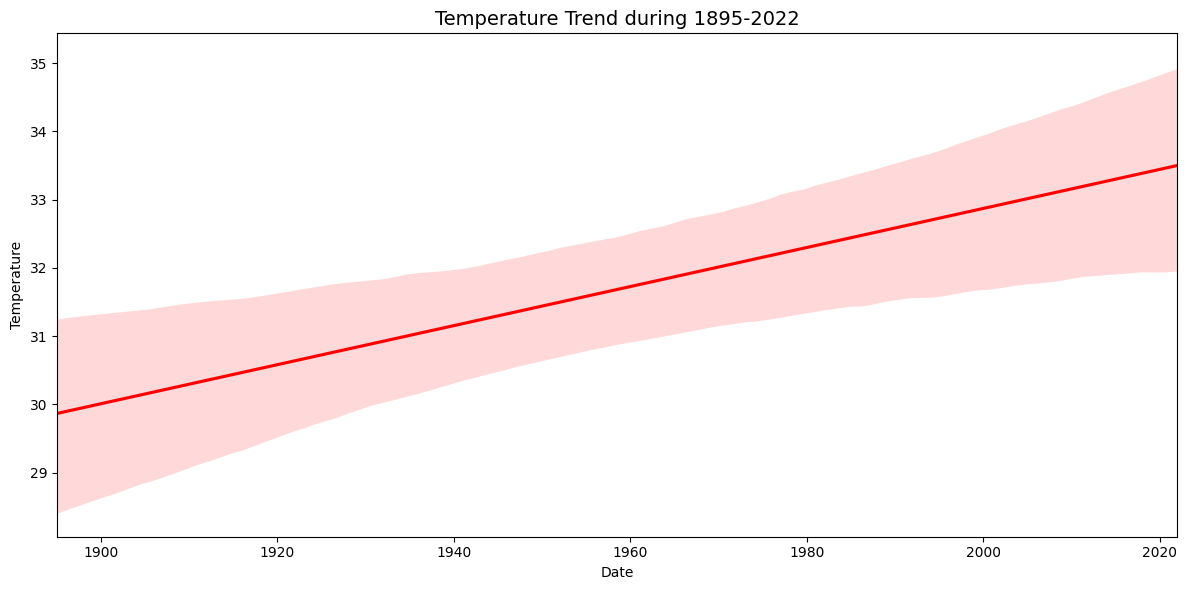

In [10]:
plt.figure(figsize=(12, 6))

ax = sns.regplot(
    data=nyc_df, 
    x='Date', 
    y='Temperature', 
    scatter=False,
    color='red'
)

plt.xlim(1895, 2022)
plt.title('Temperature Trend during 1895-2022', fontsize=14)
plt.tight_layout()

**Прогноз на найближчі роки (2023–2026)**

Спираючись на обчислені коефіцієнти регресії (m та b), ми можемо екстраполювати тенденцію в майбутнє. Для цього в циклі розраховуємо очікувану (прогнозовану) температуру для періоду з 2023 по 2026 рік за формулою прямої: 
Prediction = m * year + b.

Отримані значення ми не лише виводимо на екран, але й зберігаємо у словник `predictions`, щоб у подальшому використати їх для оцінки точності моделі (порівняння фактичних даних з прогнозом).

In [11]:
m = linear_regression.slope
b = linear_regression.intercept
predictions = {}

print("Forecast:")
for year in range(2023, 2027):
    prediction = m * year + b
    predictions[year] = prediction
    print(f"{year} year: {prediction:.2f}")

Forecast:
2023 year: 33.53
2024 year: 33.56
2025 year: 33.58
2026 year: 33.61


**Ретроспективна оцінка до початку спостережень**

Модель регресії працює в обидва боки по осі часу. Щоб теоретично оцінити, якою могла бути середня температура січня до початку офіційних спостережень NOAA, ми обчислюємо прогнозні значення для періоду з 1890 по 1894 рік.

Цей розрахунок цікавий суто з аналітичної точки зору: він дозволяє уявити кліматичну норму кінця XIX століття згідно з математичною моделлю, побудованою на подальшому тренді.

In [12]:
print("Backcast:")
for year in range(1890, 1895):
    prediction = m * year + b
    predictions[year] = prediction
    print(f"{year} year: {prediction:.2f}")

Backcast:
1890 year: 29.72
1891 year: 29.75
1892 year: 29.78
1893 year: 29.81
1894 year: 29.84


**Комплексна візуалізація: фактичні дані та тренд (1895-2026)**

На цьому етапі об'єднуємо обидва виміри: окремі спостереження (фактичні температури кожного року) та довгострокову математичну тенденцію. Робимо це за рахунок стандартної поведінки `sns.regplot`, де `scatter=True` встановлено за замовчуванням.

На графіку видно, що точки даних (кожен січень) формують значну хмару розкиду, так звану дисперсію. Сильні міжрічні коливання (теплі і холодні зими) є цілком природним явищем, проте червона лінія чітко показує невідворотний загальний напрямок — поступове потепління протягом усього досліджуваного періоду.

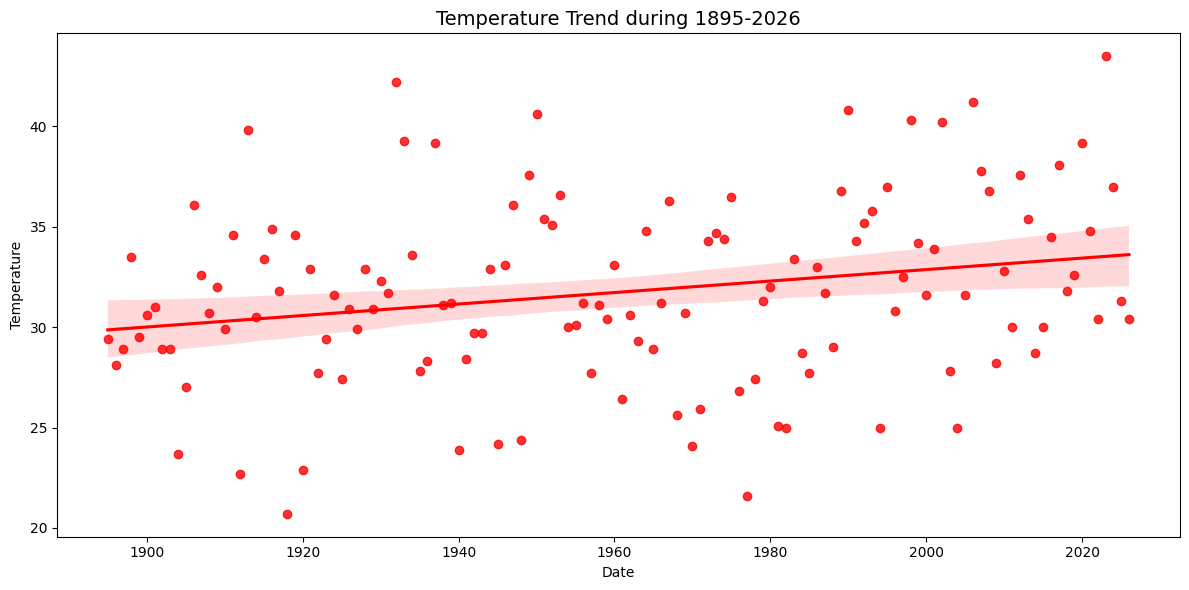

In [13]:
plt.figure(figsize=(12, 6))

axes = sns.regplot(
    data=nyc_df, 
    x='Date', 
    y='Temperature',
    color='red'
)

plt.title('Temperature Trend during 1895-2026', fontsize=14)
plt.tight_layout()

**Масштабування осі Y**

Для зручнішого сприйняття амплітуди коливань ми примусово обмежуємо вісь Y в діапазоні температур від 10 до 70 градусів за Фаренгейтом за допомогою методу `set_ylim`. Це дає змогу оцінити розмах температурних стрибків відносно більш широкої температурної шкали та стандартизувати вигляд графіка.

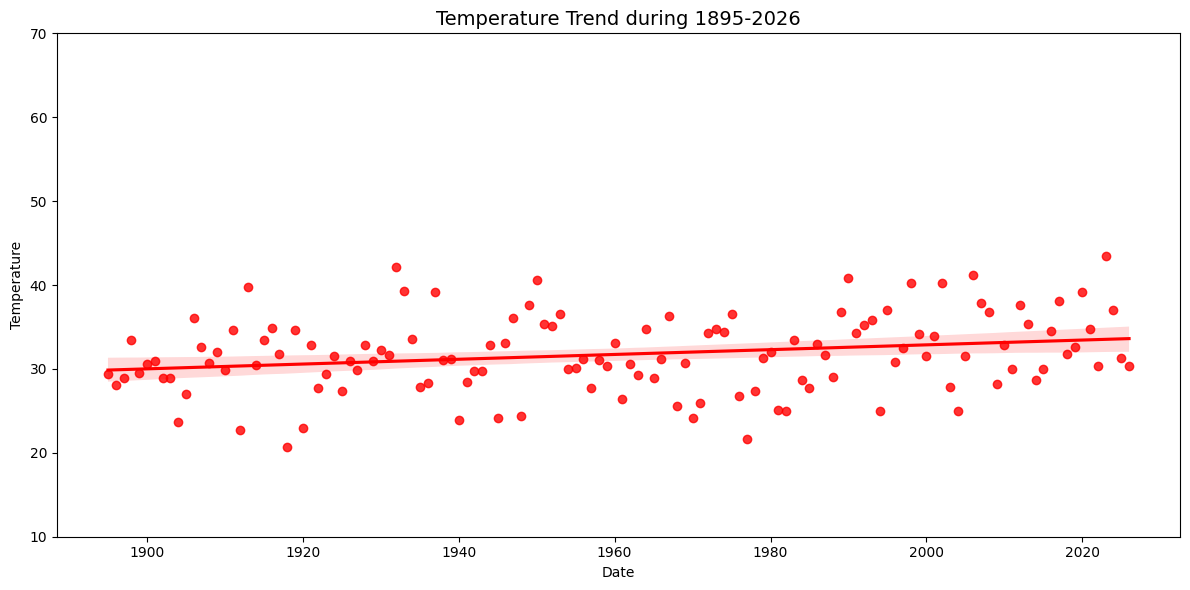

In [14]:
axes.set_ylim(10, 70)
axes.figure

**Оцінка точності моделі: порівняння прогнозу з фактичними даними**

Gорівнюються теоретичні розрахунки нашої моделі з реальними спостереженнями за період 2023-2026 років, що збережені в датасеті.

Для об'єктивної оцінки ми розраховуємо MAE (Середню абсолютну похибку), яка показує, на скільки градусів у середньому наша проста лінійна модель помиляється. 

Оскільки клімат має значну природну міжрічну мінливість (різкі коливання від року до року), прогнози лінійної регресії майже ніколи точно не співпадають із фактом конкретного року. Модель добре описує загальний довгостроковий тренд, проте є занадто спрощеною для передбачення точної погоди у конкретний сезон, оскільки не враховує складних кліматичних явищ.

In [15]:
years_to_check = range(2023, 2027)

comparison_df = (
    nyc_df[nyc_df["Date"].isin(years_to_check)][["Date", "Temperature"]]
    .rename(columns={"Date": "Year", "Temperature": "Actual"})
    .sort_values("Year")
    .reset_index(drop=True)
)

comparison_df["Predicted"] = comparison_df["Year"].map(predictions)
comparison_df["AbsError"] = (comparison_df["Predicted"] - comparison_df["Actual"]).abs()

display(comparison_df)

mae = comparison_df["AbsError"].mean()

print(f"Mean Absolute Error: {mae:.2f} °F")

,Year,Actual,Predicted,AbsError
0,2023,43.5,33.53,9.97
1,2024,37.0,33.56,3.44
2,2025,31.3,33.58,2.28
3,2026,30.4,33.61,3.21


Mean Absolute Error: 4.73 °F
